# Adaptive Landscapes

This notebook generates the adaptive-landscape figures for the streamlined VEGF–GLUT1 project.

## What this notebook does
- imports the model code from the `utils` package
- defines shared plotting helpers once at the top of the notebook
- recreates the **fixed-neighborhood ESS** adaptive landscapes
- recreates the **dynamic-neighborhood ESS** adaptive landscapes
- writes the figures to the appropriate `outputs/` folders

## Notes
- The notebook is designed to run top to bottom.
- Helper functions, styling, and imports are defined only once near the top of the notebook.
- The fixed-neighborhood subplot titles use \(u_{ESS}\) and \(y_{ESS}\), as requested.
- The dynamic-neighborhood panel uses the old working trajectory-based plotting logic.

In [1]:
# ------------------------------ Setup ---------------------------------
# Standard library imports
from pathlib import Path
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Ensure the project root is on sys.path so the utils package is importable.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Project model imports
from utils.fixed_neighborhood import integrate_fixedN
from utils.evolving_neighborhood import integrate_ess
from utils.model_params import fixedN_defaults, evolving_defaults, to_dict

print(f"Using project root: {PROJECT_ROOT}")
print("Imports loaded successfully.")

Using project root: C:\Users\80019048\Projects\Modeling VEGF and GLUT1 Expression as Coadaptive Foraging Strategies in Cancer
Imports loaded successfully.


In [2]:
# ---------------------- Shared defaults and style ----------------------
# Fixed-neighborhood parameters used for the fixed adaptive landscapes.
fixed_params_obj = fixedN_defaults(sigma_u=0.8, sigma_y=0.8, t_max=100000.0)

# Dynamic-neighborhood parameters used only to refresh the evolving ESS workbook
# if you choose to regenerate it elsewhere in the project.
dyn_params_obj = evolving_defaults(sigma_u=0.8, sigma_y=0.8, t_max=500000.0)

# Dict versions are convenient for the adaptive payoff helper below.
p_fixed = to_dict(fixed_params_obj)
p_dyn = to_dict(dyn_params_obj)

# Initial conditions used across the project notebooks.
N0 = 5.0
u0 = 0.5
y0 = 0.5

# Common plotting style
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.rcParams["savefig.transparent"] = False
mpl.rcParams["path.simplify"] = True
plt.rcParams.update({
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

# Output folders
FIXED_OUT_DIR = PROJECT_ROOT / "outputs" / "fixed_neighborhoods" / "adaptive_landscapes"
DYNAMIC_OUT_DIR = PROJECT_ROOT / "outputs" / "evolving_neighborhoods" / "adaptive_landscapes"
FIXED_OUT_DIR.mkdir(parents=True, exist_ok=True)
DYNAMIC_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Fixed adaptive landscapes:", FIXED_OUT_DIR)
print("Dynamic adaptive landscapes:", DYNAMIC_OUT_DIR)

Fixed adaptive landscapes: C:\Users\80019048\Projects\Modeling VEGF and GLUT1 Expression as Coadaptive Foraging Strategies in Cancer\outputs\fixed_neighborhoods\adaptive_landscapes
Dynamic adaptive landscapes: C:\Users\80019048\Projects\Modeling VEGF and GLUT1 Expression as Coadaptive Foraging Strategies in Cancer\outputs\evolving_neighborhoods\adaptive_landscapes
Dynamic ESS parameters used for source trajectories: EvolvingParams(b=1.0, R=100.0, a=0.05, k=0.05, c=0.01, h=0.01, f=0.005, sigma_u=0.8, sigma_y=0.8, t_max=500000.0, atol=1e-09, rtol=1e-07, max_step=50.0, e=1.0, d=1.0, m_G=0.0, m_A=0.0, t_drug=inf, N_floor=1.0, u_eps=1e-08)


In [3]:
# ------------------------------ Helpers --------------------------------
def G_adaptive(N, u_res, v, y, q, p):
    """Adaptive-landscape payoff for a mutant with trait v in resident background u_res."""
    eps = 1e-12
    x = v + u_res * (N - 1.0)
    x_safe = np.where(np.abs(x) < eps, eps, x)
    share = q / N + (1.0 - q) * (v / x_safe)
    term_y = 1.0 - np.exp(-p["k"] * y)
    term_x = 1.0 - np.exp(-p["a"] * x)
    payoff = term_y * share * p["R"] * term_x - p["c"] * v - p["h"] * y - p["f"]
    return p["b"] * payoff


def fmt_plain(x, digits=3):
    """Format a float in plain decimal notation without scientific notation."""
    return np.format_float_positional(float(x), precision=digits, trim="-")

def get_col(df: pd.DataFrame, *aliases: str) -> pd.Series:
    """Return the first matching column, allowing simple alias names."""
    m = {c.strip().lower(): c for c in df.columns}
    for name in aliases:
        key = name.strip().lower()
        if key in m:
            return df[m[key]]
    raise KeyError(f"None of {aliases} found. Columns: {list(df.columns)}")

def nearest_indices_no_dupes(t: np.ndarray, targets: list) -> np.ndarray:
    """Pick nearest time indices without allowing duplicate index reuse."""
    used, out = set(), []
    for val in targets:
        for k in np.argsort(np.abs(t - val)):
            k = int(k)
            if k not in used:
                used.add(k)
                out.append(k)
                break
    return np.array(out, dtype=int)

def build_row_norms(z_cache, row_keys, col_keys):
    """Build symmetric color norms row-by-row so each row gets its own scale."""
    row_minmax = {}
    row_norm = {}
    for row in row_keys:
        zmins, zmaxs = [], []
        for col in col_keys:
            Z = z_cache[(row, col)]
            zmins.append(float(np.nanmin(Z)))
            zmaxs.append(float(np.nanmax(Z)))
        zmin_row, zmax_row = min(zmins), max(zmaxs)
        row_minmax[row] = (zmin_row, zmax_row)
        bound = max(abs(zmin_row), abs(zmax_row))
        if (not np.isfinite(bound)) or (bound < 1e-12):
            bound = 1.0
        pad = 0.10 * bound
        row_norm[row] = TwoSlopeNorm(vmin=-(bound + pad), vcenter=0.0, vmax=(bound + pad))
    return row_minmax, row_norm

def sheet_name_for_fixed(E: pd.ExcelFile, N: int, q: float) -> str:
    """Find the matching fixed-neighborhood sheet name for a given (N, q)."""
    tgtN, tgtQ = f"n={int(N)}", f"q={q:.1f}"
    for s in E.sheet_names:
        k = s.lower().replace(" ", "")
        if tgtN in k and tgtQ in k:
            return s
    alt = f"N={int(N)} | q={q:.1f}"
    return alt if alt in E.sheet_names else E.sheet_names[0]

def col_to_numpy(df: pd.DataFrame, *aliases: str) -> np.ndarray:
    """Return a matching column as a float numpy array."""
    return get_col(df, *aliases).to_numpy(dtype=float)

## Fixed neighborhood

This section recreates the manuscript-style **fixed-neighborhood ESS adaptive landscapes**.

Workflow in this cell:
- run the fixed-neighborhood ESS simulations for `q = 0.1, 0.9` and `N = 1, 2, 5, 10, 50`
- save the trajectories to a workbook in the new project output directory
- rebuild the 3D adaptive landscapes from that workbook
- show the ESS trajectory as black dots and the ESS endpoint as a star

The subplot titles use \(u_{ESS}\) and \(y_{ESS}\), as requested.

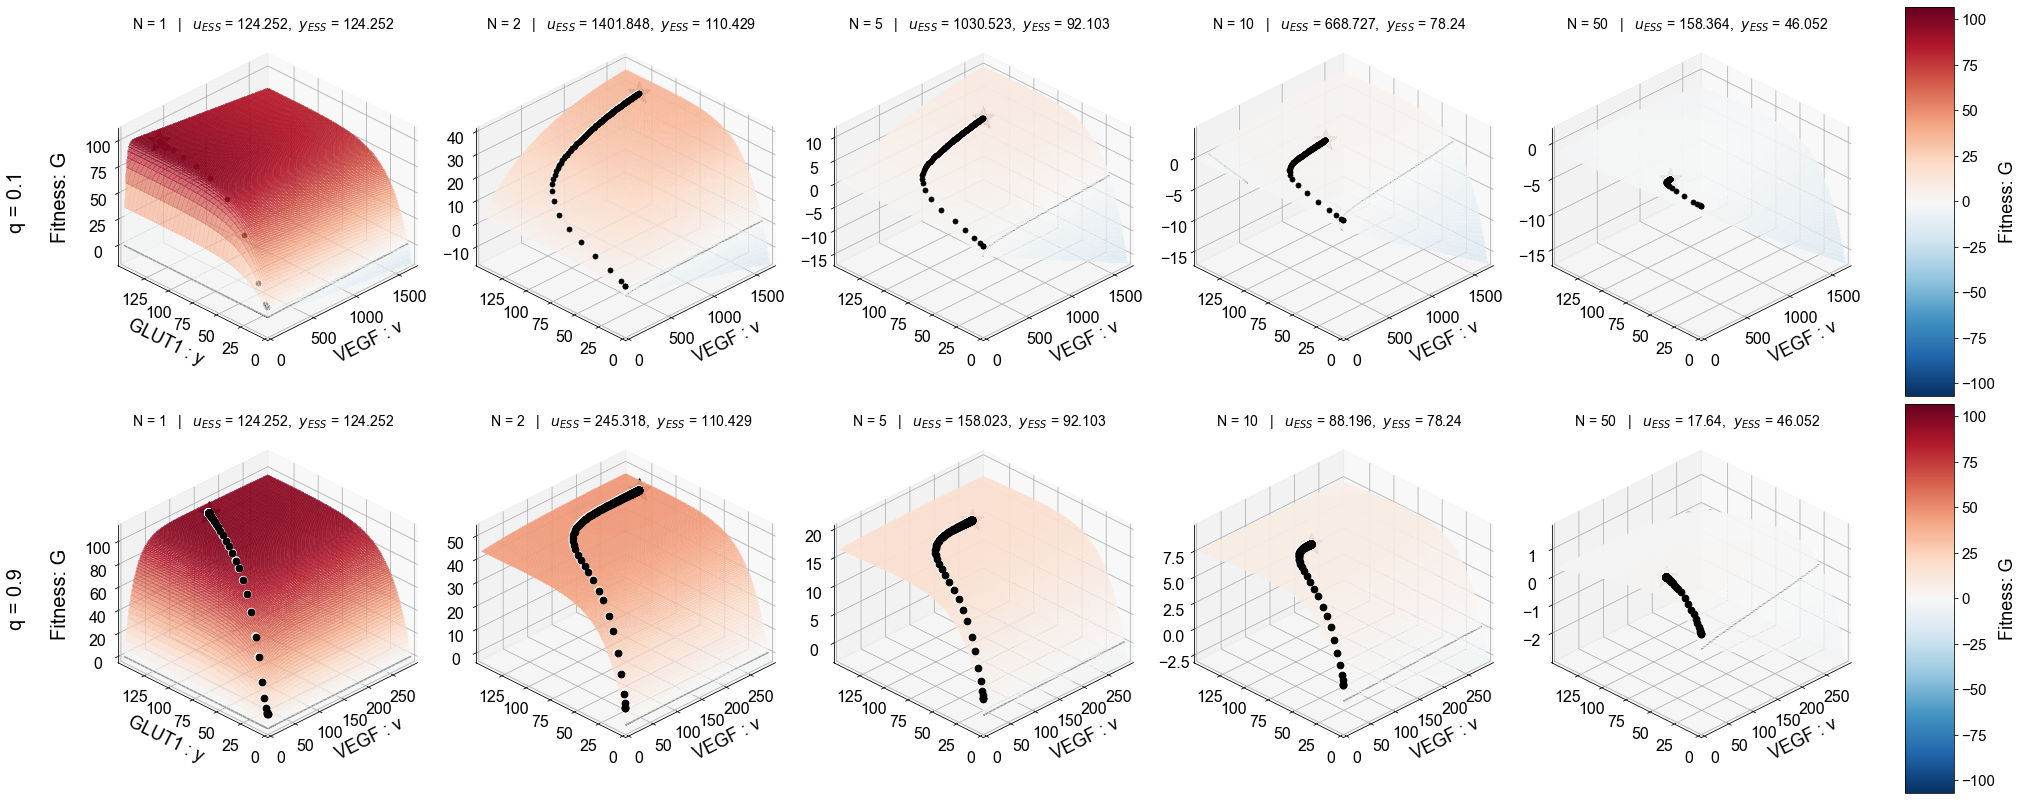

Saved 3D panel to: C:\Users\80019048\Projects\Modeling VEGF and GLUT1 Expression as Coadaptive Foraging Strategies in Cancer\outputs\fixed_neighborhoods\adaptive_landscapes


In [4]:
# === Fixed-Neighborhood ESS adaptive landscapes (3D) ==========================
# 2 rows (q = 0.1, 0.9) × 5 cols (N = 1, 2, 5, 10, 50)

# ---------------- Build / refresh the source workbook ----------------
ESS_XLSX = PROJECT_ROOT / "outputs" / "fixed_neighborhoods" / "ESS_dynamics" / "long_eqb_time" / "fixed_neighborhood_fixed_q_varying_N_data.xlsx"
ESS_XLSX.parent.mkdir(parents=True, exist_ok=True)

q_rows = (0.1, 0.9)
N_cols = (1, 2, 5, 10, 50)

with pd.ExcelWriter(ESS_XLSX, engine="xlsxwriter") as writer:
    for q in q_rows:
        for N in N_cols:
            res = integrate_fixedN(q=q, N=N, p=fixed_params_obj, u0=u0, y0=y0)
            pd.DataFrame({"t": res["t"], "u": res["u"], "y": res["y"]}).to_excel(
                writer, sheet_name=f"N={N} | q={q:.1f}", index=False
            )

# ---------------- Load trajectories and ESS endpoints ----------------
xls = pd.ExcelFile(ESS_XLSX)
traj = {}
u_star_map, y_star_map = {}, {}

for q in q_rows:
    for N in N_cols:
        s = sheet_name_for_fixed(xls, N, q)
        df = pd.read_excel(xls, sheet_name=s)
        t = col_to_numpy(df, "t", "time")
        u = col_to_numpy(df, "u")
        y = col_to_numpy(df, "y")
        traj[(q, N)] = {"t": t, "u": u, "y": y}
        u_star_map[(q, N)] = float(u[-1])
        y_star_map[(q, N)] = float(y[-1])

# ---------------- Build per-row meshes from ESS endpoint ranges ----------------
RANGE_PAD = 1.20
v_max_by_q, y_max_by_q = {}, {}
for q in q_rows:
    ustars = [u_star_map[(q, N)] for N in N_cols]
    ystars = [y_star_map[(q, N)] for N in N_cols]
    v_max_by_q[q] = max(1.0, max(ustars) * RANGE_PAD)
    y_max_by_q[q] = max(1.0, max(ystars) * RANGE_PAD)

GRID_V, GRID_Y = 180, 180
mesh_by_q = {}
for q in q_rows:
    v_vals = np.linspace(0.0, v_max_by_q[q], GRID_V)
    y_vals = np.linspace(0.0, y_max_by_q[q], GRID_Y)
    mesh_by_q[q] = np.meshgrid(v_vals, y_vals)

# ---------------- Compute surfaces and row-wise color scales ----------------
cmap = mpl.cm.RdBu_r
Z_cache = {}
for q in q_rows:
    V, Y = mesh_by_q[q]
    for N in N_cols:
        u_res = u_star_map[(q, N)]
        Z_cache[(q, N)] = G_adaptive(N=N, u_res=u_res, v=V, y=Y, q=q, p=p_fixed)

row_minmax, row_norm = build_row_norms(Z_cache, q_rows, N_cols)

# ---------------- Plot styling tuned to match the old notebook ----------------
ELEV, AZIM = 30, -135
STAR_COLOR = "#E31A1C"
DOTS_PER_Q = {0.1: 140, 0.9: 320}
SIZE_PER_Q = {0.1: 26, 0.9: 44}
EDGEW_PER_Q = {0.1: 0.7, 0.9: 1.1}
HALO_SCALE = 1.8
LIFT_PER_Q = {0.1: 0.08, 0.9: 0.12}

fig3D, axes3D = plt.subplots(
    nrows=len(q_rows), ncols=len(N_cols),
    subplot_kw={"projection": "3d"},
    figsize=(28, 11),
    constrained_layout=True
)
axes3D = np.atleast_2d(axes3D)

for i, q in enumerate(q_rows):
    V, Y = mesh_by_q[q]
    norm_q = row_norm[q]

    for j, N in enumerate(N_cols):
        ax = axes3D[i, j]
        Z = Z_cache[(q, N)]
        gmin, gmax = float(np.nanmin(Z)), float(np.nanmax(Z))
        z_span_local = max(gmax - gmin, 1e-12)

        # Surface
        ax.plot_surface(
            V, Y, Z,
            facecolors=cmap(norm_q(Z)),
            rstride=1, cstride=1,
            linewidth=0, antialiased=False,
            shade=False, alpha=0.40, rasterized=True
        )
        try:
            ax.set_proj_type("ortho")
        except Exception:
            pass

        # Zero contour for orientation
        if gmin <= 0.0 <= gmax:
            ax.contour(V, Y, Z, levels=[0.0], colors="k", linewidths=1.4, offset=0.0, zdir="z")

        # ESS endpoint and trajectory
        u_star = u_star_map[(q, N)]
        y_star = y_star_map[(q, N)]
        z_star = float(G_adaptive(N=N, u_res=u_star, v=u_star, y=y_star, q=q, p=p_fixed))
        z_star_plot = z_star + LIFT_PER_Q[q] * z_span_local

        ax.scatter([u_star], [y_star], [z_star_plot], marker="*", s=520, c=STAR_COLOR,
                   edgecolors="k", linewidths=1.6, depthshade=False, zorder=20)

        t, u, y = traj[(q, N)]["t"], traj[(q, N)]["u"], traj[(q, N)]["y"]
        if len(t) > 3:
            step = max(1, len(t) // DOTS_PER_Q[q])
            pick = np.arange(0, len(t), step)
            v_path = u[pick]
            y_path = y[pick]
            z_path = G_adaptive(N=N, u_res=u_star, v=v_path[None, :], y=y_path[None, :], q=q, p=p_fixed).ravel()
            z_path_plot = z_path + 0.05 * z_span_local

            ax.scatter(v_path, y_path, z_path_plot,
                       s=SIZE_PER_Q[q] * HALO_SCALE, c="white", edgecolors="none",
                       depthshade=False, alpha=1.0, zorder=8)
            ax.scatter(v_path, y_path, z_path_plot,
                       s=SIZE_PER_Q[q], c="k", edgecolors="white",
                       linewidths=EDGEW_PER_Q[q], depthshade=False, alpha=0.98, zorder=9)

        # Titles and row labels
        ax.set_title(f"N={N} | $u_{{ESS}}$={fmt_plain(u_star, 3)}, $y_{{ESS}}$={fmt_plain(y_star, 3)}", fontsize=18)
        if j == 0:
            row_lab = "Low Resource Sharing (q = 0.1)" if q == 0.1 else "High Resource Sharing (q = 0.9)"
            ax.text2D(-0.18, 0.50, row_lab, transform=ax.transAxes,
                      ha="right", va="center", fontsize=18, rotation=90)

        # Axis labels and limits
        ax.set_xlabel("VEGF: v", fontsize=18, labelpad=14)
        ax.set_ylabel("GLUT1: y", fontsize=18, labelpad=14)
        if j == 0:
            ax.zaxis.set_rotate_label(True)
            ax.set_zlabel("Fitness: G", rotation=0, fontsize=18, labelpad=12)
        else:
            ax.set_zlabel("")
        ax.view_init(ELEV, AZIM)
        ax.set_xlim(0, v_max_by_q[q])
        ax.set_ylim(0, 2500)  # requested fixed-neighborhood VEGF/GLUT axis range

        zlo = min(gmin, 0.0)
        zhi = max(gmax, z_star_plot) + 0.06 * z_span_local
        ax.set_zlim(zlo, zhi)

        ax.tick_params(axis="x", labelsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.tick_params(axis="z", labelsize=14)

# Colorbar for each row
for i, q in enumerate(q_rows):
    sm_row = mpl.cm.ScalarMappable(norm=row_norm[q], cmap=cmap)
    sm_row.set_array([])
    cb = plt.colorbar(sm_row, ax=axes3D[i, :].ravel().tolist(), fraction=0.016, pad=0.02)
    cb.set_label("Fitness: G", fontsize=18)
    cb.ax.tick_params(labelsize=14)

# Save outputs
fixed_png = FIXED_OUT_DIR / "fixed_neighborhood_ess_adaptive_landscapes_3d.png"
fixed_svg = FIXED_OUT_DIR / "fixed_neighborhood_ess_adaptive_landscapes_3d.svg"
fig3D.savefig(fixed_png, dpi=300, bbox_inches="tight")
fig3D.savefig(fixed_svg, format="svg", bbox_inches="tight", metadata={"Date": None})

print("Saved fixed adaptive landscapes to:", FIXED_OUT_DIR)
plt.show()

## Dynamic neighborhood

This section recreates the manuscript-style **evolving-neighborhood ESS adaptive landscapes** using the old working logic.

Workflow in this cell:
- read the evolving-neighborhood ESS workbook
- extract the exact requested time points for `q = 0.1` and `q = 0.9`
- rebuild the 3D adaptive landscapes from those time slices
- draw the black trajectory dots and endpoint star exactly as in the earlier notebook

The only cleanup here is structural: imports, helpers, and styling are defined above so the plotting cell stays focused on the dynamic-figure logic.

Saved 3D panel to: outputs\evolving_neighborhoods\adaptive_landscapes


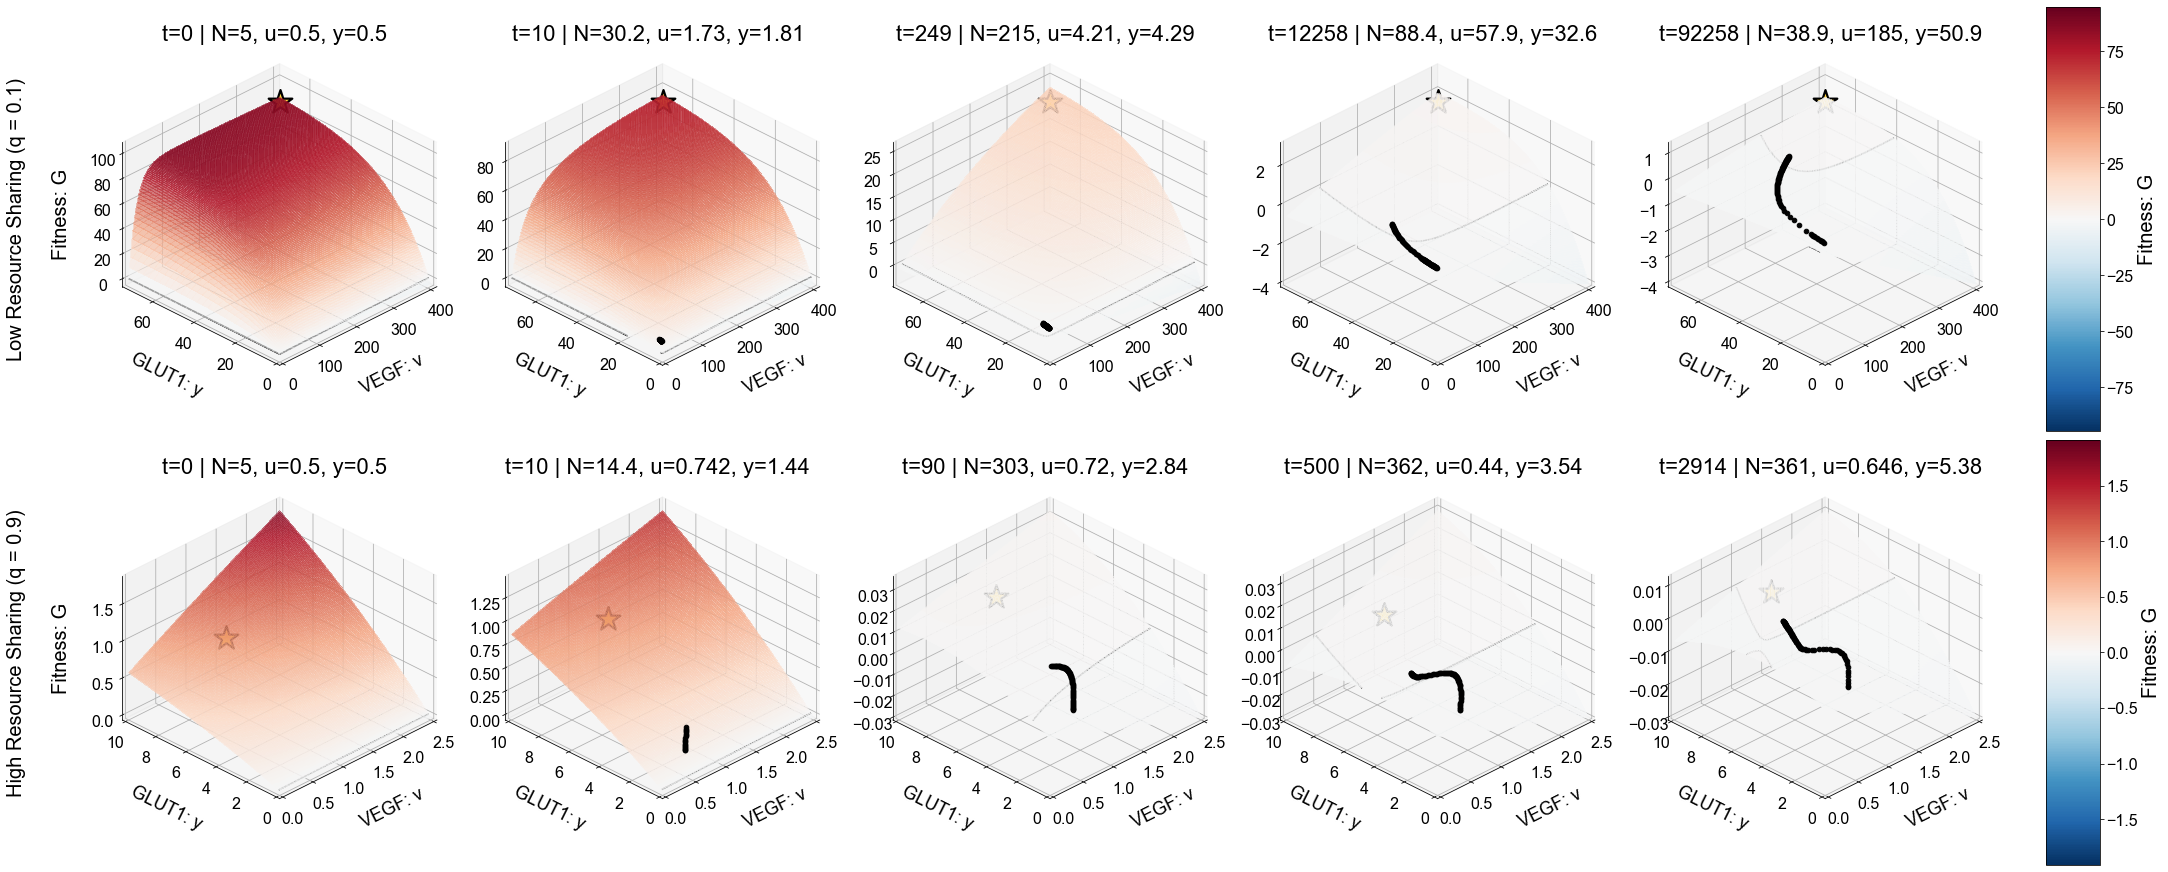

In [7]:
# === Evolving-N adaptive landscapes (3D surfaces) ============================
# This cell intentionally keeps the old working plotting logic, while relying on
# the shared imports and helper functions defined earlier in the notebook.

# ---------------- Input workbook and requested time points ----------------
EV_XLSX = PROJECT_ROOT / "outputs" / "evolving_neighborhoods" / "ESS_dynamics" / "long_eqb_time" / "Evolving_Neighborhood_Varying_ESS_q_data.xlsx"
if not EV_XLSX.exists():
    raise FileNotFoundError(f"Missing workbook: {EV_XLSX}")

requested_times = {
    0.1: [0, 10, 250, 12260, 92260],
    0.9: [0, 10, 90, 500, 2916],
}
qs = (0.1, 0.9)

# ---------------- Load evolving-N trajectories from the workbook ----------------
runs = {}
xls = pd.ExcelFile(EV_XLSX)
for q in qs:
    df = pd.read_excel(xls, sheet_name=f"q={q:.1f}")
    t = get_col(df, "t", "time").to_numpy(dtype=float)
    N = get_col(df, "n").to_numpy(dtype=float)
    u = get_col(df, "u").to_numpy(dtype=float)
    y = get_col(df, "y").to_numpy(dtype=float)
    runs[q] = {"t": t, "N": N, "u": u, "y": y}

# Pick the requested times without allowing duplicate index reuse.
sel_idx = {q: nearest_indices_no_dupes(runs[q]["t"], requested_times[q]) for q in qs}

# ---------------- Build q-specific meshes ----------------
RANGE_PAD = 1.20
V_MAX_Q09, Y_MAX_Q09 = 2.5, 10.0
v_max_by_q, y_max_by_q = {}, {}
v_max_by_q[0.1] = max(1.0, float(np.nanmax(runs[0.1]["u"])) * RANGE_PAD)
y_max_by_q[0.1] = max(1.0, float(np.nanmax(runs[0.1]["y"])) * RANGE_PAD)
v_max_by_q[0.9] = max(1.0, V_MAX_Q09, float(np.nanmax(runs[0.9]["u"])) * RANGE_PAD)
y_max_by_q[0.9] = max(1.0, Y_MAX_Q09, float(np.nanmax(runs[0.9]["y"])) * RANGE_PAD)

GRID_V, GRID_Y = 180, 180
mesh_by_q = {}
for q in qs:
    v_vals = np.linspace(0.0, v_max_by_q[q], GRID_V)
    y_vals = np.linspace(0.0, y_max_by_q[q], GRID_Y)
    mesh_by_q[q] = np.meshgrid(v_vals, y_vals)

# ---------------- Compute each requested surface ----------------
Z_cache = {}
for q in qs:
    V, Y = mesh_by_q[q]
    r = runs[q]
    for j, k in enumerate(sel_idx[q]):
        Ni, ui = r["N"][k], r["u"][k]
        Z_cache[(q, j)] = G_adaptive(N=Ni, u_res=ui, v=V, y=Y, q=q, p=p_fixed)

# ---------------- Row-wise color scales ----------------
norm_row, row_bounds = {}, {}
for q in qs:
    zmins, zmaxs = [], []
    for j in range(len(sel_idx[q])):
        Z = Z_cache[(q, j)]
        zmins.append(float(np.nanmin(Z)))
        zmaxs.append(float(np.nanmax(Z)))
    bound = max(abs(min(zmins)), abs(max(zmaxs)))
    if not np.isfinite(bound) or bound < 1e-12:
        bound = 1.0
    pad = 0.10 * bound
    vmin = -(bound + pad)
    vmax = +(bound + pad)
    norm_row[q] = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    row_bounds[q] = (vmin, vmax)

cmap = mpl.cm.RdBu_r

# ---------------- Plot the 3D panel ----------------
ELEV, AZIM = 30, -135
DOTS_3D = 90
STAR_COLOR = "#FFD23F"

fig3D, axes3D = plt.subplots(
    2, 5,
    subplot_kw={"projection": "3d"},
    figsize=(30, 12.0),
    constrained_layout=True
)
axes3D = np.atleast_2d(axes3D)

for i, q in enumerate(qs):
    V, Y = mesh_by_q[q]
    r = runs[q]

    for j, k in enumerate(sel_idx[q]):
        ax = axes3D[i, j]
        Z = Z_cache[(q, j)]
        facecolors = cmap(norm_row[q](Z))

        # Surface first so markers sit clearly above it.
        ax.plot_surface(
            V, Y, Z,
            facecolors=facecolors,
            rstride=1,
            cstride=1,
            linewidth=0,
            antialiased=False,
            shade=False,
            alpha=0.40,
            rasterized=True,
        )

        try:
            ax.set_proj_type("ortho")
        except Exception:
            pass

        zmin_loc = float(np.nanmin(Z))
        zmax_loc = float(np.nanmax(Z))
        if zmin_loc <= 0.0 <= zmax_loc:
            ax.contour(V, Y, Z, levels=[0.0], colors="k", linewidths=1.6, offset=0.0, zdir="z")

        # Current state for this requested time.
        t_ij = r["t"][k]
        Ni = r["N"][k]
        ui = r["u"][k]
        yi = r["y"][k]
        ax.set_title(f"t={t_ij:.0f} | N={Ni:.3g}, u={ui:.3g}, y={yi:.3g}", fontsize=22)

        # ESS endpoint star (use final u*, y* from the loaded trajectory).
        u_star = r["u"][-1]
        y_star = r["y"][-1]
        z_star = float(G_adaptive(N=Ni, u_res=ui, v=u_star, y=y_star, q=q, p=p_fixed))
        z_span_local = max(zmax_loc - zmin_loc, 1e-12)
        STAR_LIFT = (0.20 if q == 0.1 else 0.18) * z_span_local
        z_star_plot = z_star + STAR_LIFT

        ax.scatter([u_star], [y_star], [z_star_plot],
                   marker="*", s=950, c="white", edgecolors="white",
                   linewidths=0.0, depthshade=False, zorder=10000)
        ax.scatter([u_star], [y_star], [z_star_plot],
                   marker="*", s=620, c=STAR_COLOR, edgecolors="k",
                   linewidths=2.2, depthshade=False, zorder=10001)

        # Trajectory dots up to the requested time point.
        if t_ij > 1.0:
            mask = (r["t"] > 1.0) & (r["t"] <= t_ij)
            idx = np.where(mask)[0]
            if len(idx) > 0:
                pick = np.linspace(idx[0], idx[-1], min(DOTS_3D, len(idx))).round().astype(int)
                v_path = r["u"][pick]
                y_path = r["y"][pick]
                z_path = G_adaptive(
                    N=Ni,
                    u_res=ui,
                    v=v_path[None, :],
                    y=y_path[None, :],
                    q=q,
                    p=p_fixed
                ).ravel()
                ax.plot(v_path, y_path, z_path + 0.10 * z_span_local,
                        "o", ms=4.6, color="k", alpha=0.98, zorder=1000)

        # Row label only on the first subplot of each row.
        if j == 0:
            row_lab = "Low Resource Sharing (q = 0.1)" if q == 0.1 else "High Resource Sharing (q = 0.9)"
            ax.text2D(-0.22, 0.5, row_lab, transform=ax.transAxes,
                      ha="right", va="center", fontsize=20, rotation=90)

        # Axes / labels / limits
        ax.set_xlabel("VEGF: v", fontsize=18, labelpad=18)
        ax.set_ylabel("GLUT1: y", fontsize=18, labelpad=22)
        if j == 0:
            ax.zaxis.set_rotate_label(True)
            ax.set_zlabel("Fitness: G", rotation=0, fontsize=20, labelpad=14)
        else:
            ax.set_zlabel("")

        ax.view_init(ELEV, AZIM)
        ax.set_xlim(0, v_max_by_q[q])
        ax.set_ylim(0, y_max_by_q[q])

        zlo = min(zmin_loc, 0.0)
        zhi = max(zmax_loc, 0.0, z_star_plot) + 0.06 * z_span_local
        ax.set_zlim(zlo, zhi)

        # Keep y ticks readable and away from the surface.
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=14, pad=10)
        ax.tick_params(axis="z", labelsize=16)
        ax.yaxis.set_major_locator(MaxNLocator(5))

# Independent colorbars per row
for i, q in enumerate(qs):
    sm_row = mpl.cm.ScalarMappable(norm=norm_row[q], cmap=cmap)
    sm_row.set_array([])
    cb = plt.colorbar(sm_row, ax=axes3D[i, :].ravel().tolist(), fraction=0.016, pad=0.02)
    cb.set_label("Fitness: G", fontsize=20)
    cb.ax.tick_params(labelsize=16)

# ---------------- Save outputs ----------------
dynamic_png = DYNAMIC_OUT_DIR / "evN_adaptive_landscapes_requested_times_3D.png"
dynamic_svg = DYNAMIC_OUT_DIR / "evN_adaptive_landscapes_requested_times_3D.svg"
fig3D.savefig(dynamic_png, dpi=300, bbox_inches="tight")
fig3D.savefig(dynamic_svg, format="svg", bbox_inches="tight", metadata={"Date": None})

print("Saved dynamic adaptive landscapes to:", DYNAMIC_OUT_DIR)
plt.show()